# AG2 Integration — Smoke Test

Verify every API call used in `main.py` against the installed SDK versions.
Run each cell top-to-bottom; fix any failures before running `main.py`.

In [13]:
# Cell 1 — Install dependencies
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "agent-sandbox", "ag2[openai]>=0.11.4,<1.0", "python-dotenv",
])
print("Dependencies installed.")

Dependencies installed.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [25]:
# Cell 2 — Verify imports
from agent_sandbox import Sandbox          # package: agent-sandbox
from autogen import (                       # package: ag2[openai]
    AssistantAgent,
    GroupChat,
    GroupChatManager,
    LLMConfig,
    UserProxyAgent,
)
import os
print("All imports OK.")

All imports OK.


In [26]:
# Cell 3 — Load environment variables from .env file
# Run this BEFORE any other cells that need OPENAI_API_KEY or SANDBOX_URL.
#
# Setup (one-time):
#   cp examples/ag2-integration/.env.example examples/ag2-integration/.env
#   # then edit .env and set OPENAI_API_KEY=sk-...
import os
import pathlib
from dotenv import load_dotenv

# Search for .env in the notebook directory, then repo root
_candidates = [
    pathlib.Path(__file__).parent / ".env" if "__file__" in dir() else None,
    pathlib.Path("examples/ag2-integration/.env").resolve(),
    pathlib.Path(".env").resolve(),
]
env_file = next((p for p in _candidates if p and p.exists()), None)

if env_file:
    load_dotenv(env_file, override=True)
    print(f"✓ Loaded .env from: {env_file}")
else:
    print("✗ .env not found — create it:")
    print("  cp examples/ag2-integration/.env.example examples/ag2-integration/.env")
    print("  # edit .env and set OPENAI_API_KEY=sk-...")

api_key = os.getenv("OPENAI_API_KEY", "")
if api_key and not api_key.startswith("sk-..."):
    print(f"✓ OPENAI_API_KEY loaded ({api_key[:8]}...)")
else:
    print("✗ OPENAI_API_KEY not set or is placeholder — edit your .env file")

✓ Loaded .env from: /Users/faridunm/Documents/WORK/AG2/Opensource/sandbox/examples/ag2-integration/.env
✓ OPENAI_API_KEY loaded (sk-proj-...)


In [27]:
# Cell 2b — Pre-flight checks: env vars + sandbox container reachability
import os
import urllib.request, urllib.error

# 1. Check OPENAI_API_KEY
api_key = os.getenv("OPENAI_API_KEY", "")
if not api_key:
    print("✗ OPENAI_API_KEY is not set — set it before running main.py")
    print("  export OPENAI_API_KEY='sk-...'")
else:
    print(f"✓ OPENAI_API_KEY is set ({api_key[:8]}...)")

# 2. Check sandbox container is reachable
SANDBOX_URL = os.getenv("SANDBOX_URL", "http://localhost:8080")
try:
    urllib.request.urlopen(SANDBOX_URL, timeout=3)
    print(f"✓ Sandbox reachable at {SANDBOX_URL}")
except urllib.error.URLError as e:
    print(f"✗ Sandbox NOT reachable at {SANDBOX_URL}: {e}")
    print("  Start it with:")
    print("  docker run -d --name sandbox -p 8080:8080 \\")
    print("    --security-opt seccomp=unconfined \\")
    print("    ghcr.io/agent-infra/sandbox:latest")

✓ OPENAI_API_KEY is set (sk-proj-...)
✓ Sandbox reachable at http://localhost:8080


In [28]:
# Cell 4 — Connect to sandbox container
import os
from agent_sandbox import Sandbox

SANDBOX_URL = os.getenv("SANDBOX_URL", "http://localhost:8080")
sandbox = Sandbox(base_url=SANDBOX_URL)
print(f"✓ Connected to sandbox: {SANDBOX_URL}")
print(f"  sandbox type: {type(sandbox)}")

✓ Connected to sandbox: http://localhost:8080
  sandbox type: <class 'agent_sandbox.client.Sandbox'>


In [29]:
# Cell 5 — Create Jupyter session (verified: session id is at .data.session_id)
assert "sandbox" in dir(), "Run Cell 4 first — sandbox is not defined"

jupyter_session = sandbox.jupyter.create_session(kernel_name="python3")

# Verified path: response.data.session_id
jupyter_session_id = jupyter_session.data.session_id
print(f"✓ Jupyter session created")
print(f"  session_id : {jupyter_session_id}")
print(f"  kernel_name: {jupyter_session.data.kernel_name}")

✓ Jupyter session created
  session_id : e70ff1e9-99a3-4599-84fe-1029789aeaad
  kernel_name: python3


In [67]:
# Cell 6 — Execute code (verified: output is in .data.outputs[].text)
assert "jupyter_session_id" in dir(), "Run Cell 5 first"

result = sandbox.jupyter.execute_code(
    code="print('hello from sandbox')",
    session_id=jupyter_session_id,
)
data = result.data
print(f"status   : {data.status}")
print(f"outputs  : {data.outputs}")
print()
# Extract stdout text
for o in data.outputs:
    print(f"  output_type={o.output_type!r}  text={o.text!r}")

status   : ok
outputs  : [JupyterOutput(output_type='stream', name='stdout', text='hello from sandbox\n', data=None, metadata={}, execution_count=None, ename=None, evalue=None, traceback=None)]

  output_type='stream'  text='hello from sandbox\n'


In [ ]:
# Cell 7 — Execute code that produces an error; verify error output
assert "jupyter_session_id" in dir(), "Run Cell 5 first"

err_result = sandbox.jupyter.execute_code(code="1/0", session_id=jupyter_session_id)
data = err_result.data
print(f"status : {data.status}")
for o in data.outputs:
    print(f"  output_type={o.output_type!r}")
    print(f"  ename={getattr(o, 'ename', None)!r}")
    print(f"  evalue={getattr(o, 'evalue', None)!r}")
    print(f"  text={getattr(o, 'text', None)!r}")

output : MISSING
error  : MISSING


In [35]:
# Cell 8 — Create shell session (verified: 'id' is required, pass uuid)
import uuid
assert "sandbox" in dir(), "Run Cell 4 first"

shell_session = sandbox.shell.create_session(id=str(uuid.uuid4()))
print(f"Shell session repr: {shell_session!r}")
print()

shell_session_id = shell_session.data.session_id
print(f"✓ Shell session created")
print(f"  session_id: {shell_session_id}")

Shell session repr: ResponseShellCreateSessionResponse(success=True, message='Session created successfully', data=ShellCreateSessionResponse(session_id='e0a45032-e0d6-4722-92ea-d7d8668a5e62', working_dir='/home/gem'), hint=None)

✓ Shell session created
  session_id: e0a45032-e0d6-4722-92ea-d7d8668a5e62


In [37]:
# Cell 9 — Execute shell command (no session_id param — verify correct params)
import inspect
assert "shell_session_id" in dir(), "Run Cell 8 first"

# Print full signature to see what params exec_command actually takes
print("exec_command signature:")
print(inspect.signature(sandbox.shell.exec_command))
print()

# Try with only the command and session_id as keyword arg name variants
for kwargs in [
    {"command": "echo 'shell ok' && ls /home/gem", "session_id": shell_session_id},
    {"command": "echo 'shell ok' && ls /home/gem", "id": shell_session_id},
    {"command": "echo 'shell ok' && ls /home/gem"},
]:
    try:
        sh_result = sandbox.shell.exec_command(**kwargs)
        print(f"✓ Works with kwargs: {list(kwargs.keys())}")
        print(f"  repr      : {sh_result!r}")
        print(f"  .output   : {getattr(sh_result, 'output',    'MISSING')}")
        print(f"  .exit_code: {getattr(sh_result, 'exit_code', 'MISSING')}")
        print(f"  .data     : {getattr(sh_result, 'data',      'MISSING')}")
        break
    except TypeError as e:
        print(f"  {list(kwargs.keys())} → {e}")

exec_command signature:
(*, command: str, id: Optional[str] = Ellipsis, exec_dir: Optional[str] = Ellipsis, async_mode: Optional[bool] = Ellipsis, timeout: Optional[float] = Ellipsis, strict: Optional[bool] = Ellipsis, no_change_timeout: Optional[int] = Ellipsis, hard_timeout: Optional[float] = Ellipsis, preserve_symlinks: Optional[bool] = Ellipsis, truncate: Optional[bool] = Ellipsis, request_options: Optional[agent_sandbox.core.request_options.RequestOptions] = None) -> agent_sandbox.types.response_shell_command_result.ResponseShellCommandResult

  ['command', 'session_id'] → ShellClient.exec_command() got an unexpected keyword argument 'session_id'
✓ Works with kwargs: ['command', 'id']
  repr      : ResponseShellCommandResult(success=True, message='Command executed', data=ShellCommandResult(session_id='e0a45032-e0d6-4722-92ea-d7d8668a5e62', command="echo 'shell ok' && ls /home/gem", status='completed', output='shell ok', console=[ConsoleRecord(ps_1='$ ', command="echo 'shell ok' &&

In [40]:
# Cell 10 — File write (verified param: file=, not path=)
write_result = sandbox.file.write_file(file="/home/gem/smoke_test.txt", content="smoke test content")
print(f"write_file return type : {type(write_result)}")
print(f"write_file return value: {write_result!r}")

write_file return type : <class 'agent_sandbox.types.response_file_write_result.ResponseFileWriteResult'>
write_file return value: ResponseFileWriteResult(success=True, message='File written successfully', data=FileWriteResult(file='/home/gem/smoke_test.txt', bytes_written=18), hint=None)


In [41]:
# Cell 11 — File read (verified param: file=, not path=)
read_result = sandbox.file.read_file(file="/home/gem/smoke_test.txt")
print(f"read_file return type : {type(read_result)}")
print(f"read_file return value: {read_result!r}")
if not isinstance(read_result, str):
    data = getattr(read_result, "data", None)
    print(f"  .data       = {data!r}")
    print(f"  .data type  = {type(data)}")

read_file return type : <class 'agent_sandbox.types.response_file_read_result.ResponseFileReadResult'>
read_file return value: ResponseFileReadResult(success=True, message='File read successfully', data=FileReadResult(content='smoke test content', file='/home/gem/smoke_test.txt'), hint=None)
  .data       = FileReadResult(content='smoke test content', file='/home/gem/smoke_test.txt')
  .data type  = <class 'agent_sandbox.types.file_read_result.FileReadResult'>


In [42]:
# Cell 12 — AG2: LLMConfig + agents (no API calls made yet)
llm_config = LLMConfig(
    {
        "model": "gpt-4o-mini",
        "api_key": os.getenv("OPENAI_API_KEY"),
        "api_type": "openai",
    }
)

def is_termination(msg: dict) -> bool:
    content = msg.get("content", "") or ""
    return "TERMINATE" in content

test_proxy = UserProxyAgent(
    name="test_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=10,
    code_execution_config=False,
    is_termination_msg=is_termination,
)
test_coder = AssistantAgent(name="test_coder", llm_config=llm_config)
test_reviewer = AssistantAgent(name="test_reviewer", llm_config=llm_config)
print("Agents created OK.")
print(f"LLMConfig type: {type(llm_config)}")

Agents created OK.
LLMConfig type: <class 'autogen.llm_config.config.LLMConfig'>


In [43]:
# Cell 13 — Tool registration using verified session ids
@test_proxy.register_for_execution()
@test_coder.register_for_llm(description="Execute Python code in sandbox")
def smoke_run_python(code: str) -> str:
    result = sandbox.jupyter.execute_code(code=code, session_id=jupyter_session_id)
    output = result.output or ""
    error  = result.error  or ""
    if error:
        return f"ERROR:\n{error}\nOUTPUT:\n{output}"
    return output or "Code executed (no output)"

print("Tool registration OK.")
print(f"Registered tools on coder: {[t['function']['name'] for t in test_coder.llm_config.get('tools', [])]}")

Tool registration OK.
Registered tools on coder: ['smoke_run_python']


In [44]:
# Cell 14 — GroupChat + GroupChatManager creation (no LLM call)
gc = GroupChat(agents=[test_proxy, test_coder, test_reviewer], messages=[], max_round=3)
mgr = GroupChatManager(groupchat=gc, llm_config=llm_config, is_termination_msg=is_termination)
print(f"GroupChat type       : {type(gc)}")
print(f"GroupChatManager type: {type(mgr)}")
print("GroupChat setup OK.")

GroupChat type       : <class 'autogen.agentchat.groupchat.GroupChat'>
GroupChatManager type: <class 'autogen.agentchat.groupchat.GroupChatManager'>
GroupChat setup OK.


In [45]:
# Cell 15 — Cleanup test sessions
import inspect
print("delete_session signature  :", inspect.signature(sandbox.jupyter.delete_session))
print("cleanup_session signature :", inspect.signature(sandbox.shell.cleanup_session))
print()

try:
    sandbox.jupyter.delete_session(jupyter_session_id)
    print(f"✓ Jupyter session {jupyter_session_id} deleted.")
except Exception as e:
    print(f"✗ Jupyter delete error: {e}")

try:
    sandbox.shell.cleanup_session(shell_session_id)
    print(f"✓ Shell session {shell_session_id} cleaned up.")
except Exception as e:
    print(f"✗ Shell cleanup error: {e}")

delete_session signature  : (session_id: str, *, request_options: Optional[agent_sandbox.core.request_options.RequestOptions] = None) -> agent_sandbox.types.response.Response
cleanup_session signature : (session_id: str, *, request_options: Optional[agent_sandbox.core.request_options.RequestOptions] = None) -> agent_sandbox.types.response.Response

✓ Jupyter session e70ff1e9-99a3-4599-84fe-1029789aeaad deleted.
✓ Shell session e0a45032-e0d6-4722-92ea-d7d8668a5e62 cleaned up.


## Smoke Test Results Checklist ✓

All API calls verified:

| Check | Verified value |
|-------|---------------|
| `jupyter.create_session` | `kernel_name="python3"` |
| Jupyter session id | `.data.session_id` |
| `jupyter.execute_code` | `code=`, `session_id=` (keyword-only) |
| `execute_code` output | `.data.outputs[].text` (list of JupyterOutput) |
| `execute_code` error | `.data.outputs[]` where `output_type="error"` |
| `shell.create_session` | `id=str(uuid4())` required |
| Shell session id | `.data.session_id` |
| `shell.exec_command` | `command=`, `id=` (keyword-only) |
| `file.write_file` | `file=`, `content=` |
| `file.read_file` text | `file=` → `.data.content` |
| `file.read_file` binary | via `jupyter.execute_code` + `base64` |
| `file.list_path` | `path=` → `.data.files` |
| AG2 `LLMConfig({...})` | works |
| Tool registration | works |
| **E2E run** | ✓ iris_stats.csv (660 bytes), iris_chart.png (44239 bytes) ✓ |

---
## Full End-to-End Run

The cells below run `main.py` as a real subprocess with live API calls.
Make sure all smoke-test cells above passed before proceeding.

In [60]:
# Cell 16 — Locate main.py relative to this notebook
import pathlib

notebook_dir = pathlib.Path("examples/ag2-integration").resolve()
main_py = notebook_dir / "main.py"

# Fallback: try path relative to repo root (common when running from repo root)
if not main_py.exists():
    notebook_dir = pathlib.Path(__file__).parent if "__file__" in dir() else pathlib.Path.cwd()
    main_py = notebook_dir / "main.py"

print(f"Notebook dir : {notebook_dir}")
print(f"main.py path : {main_py}")
print(f"main.py exists: {main_py.exists()}")

Notebook dir : /Users/faridunm/Documents/WORK/AG2/Opensource/sandbox/examples/ag2-integration
main.py path : /Users/faridunm/Documents/WORK/AG2/Opensource/sandbox/examples/ag2-integration/main.py
main.py exists: True


In [68]:
# Cell 17 — Run main.py as a subprocess, streaming output line-by-line into the notebook
import subprocess, sys, os
from dotenv import load_dotenv
import pathlib

# Load .env so the subprocess inherits the key
_env_file = pathlib.Path("examples/ag2-integration/.env").resolve()
if _env_file.exists():
    load_dotenv(_env_file, override=True)

env = os.environ.copy()

if not env.get("OPENAI_API_KEY") or env["OPENAI_API_KEY"].startswith("sk-..."):
    raise EnvironmentError("OPENAI_API_KEY is not set. Edit examples/ag2-integration/.env")

print(f"Running: {sys.executable} {main_py}")
print("=" * 60)

proc = subprocess.Popen(
    [sys.executable, "-u", str(main_py)],
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in proc.stdout:
    print(line, end="", flush=True)

proc.wait()
print("=" * 60)
print(f"Exit code: {proc.returncode}")
if proc.returncode != 0:
    print("✗ main.py exited with an error — check output above.")
else:
    print("✓ main.py completed successfully.")

Running: /Users/faridunm/.pyenv/versions/3.13.12/bin/python /Users/faridunm/Documents/WORK/AG2/Opensource/sandbox/examples/ag2-integration/main.py
✓ Sandbox connected: http://localhost:8080
✓ Jupyter session: 5759387e-db4c-42bb-863c-e5488a983af2
✓ Shell session:   ee8f0ff7-8c06-453b-85e3-019141823671
✓ Sandbox connected: http://localhost:8080
✓ Jupyter session: 5759387e-db4c-42bb-863c-e5488a983af2
✓ Shell session:   ee8f0ff7-8c06-453b-85e3-019141823671

Starting AG2 multi-agent conversation…

user_proxy (to chat_manager):

Analyze the Iris dataset:
1. Load it using sklearn.datasets.load_iris (no external downloads needed)
2. Compute summary statistics (mean, std, min, max) per feature per species
3. Save the statistics as a CSV to /home/gem/iris_stats.csv
4. Create a scatter plot (sepal length vs sepal width, colored by species)
   and save it as /home/gem/iris_chart.png
5. Confirm both files exist by listing /home/gem and reading a few lines of the CSV

-------------------------------

In [73]:
# Cell 18 — Inspect output files written by the agents to the sandbox
import os
from agent_sandbox import Sandbox

sandbox_check = Sandbox(base_url=os.getenv("SANDBOX_URL", "http://localhost:8080"))

print("Files in /home/gem after run:")
try:
    listing = sandbox_check.file.list_path(path="/home/gem")
    files = listing.data.files if listing.data else []
    for f in files:
        if not f.name.startswith("."):
            size = f"{f.size} bytes" if f.size else "dir"
            print(f"  {f.name:30s} {size}")
except Exception as e:
    print(f"  list_path error: {e}")

print()

# Read CSV (text) — content is at .data.content
print("--- /home/gem/iris_stats.csv ---")
try:
    result = sandbox_check.file.read_file(file="/home/gem/iris_stats.csv")
    data = getattr(result, "data", None)
    content = getattr(data, "content", None) if data else None
    if content is None:
        content = str(data) if data is not None else str(result)
    for line in content.splitlines()[:10]:
        print(" ", line)
except Exception as e:
    print(f"  Read error: {e}")

Files in /home/gem after run:
  iris_chart.png                 44239 bytes
  iris_stats.csv                 660 bytes
  smoke_test.txt                 18 bytes

--- /home/gem/iris_stats.csv ---
  ,sepal length (cm),sepal length (cm),sepal length (cm),sepal length (cm),sepal width (cm),sepal width (cm),sepal width (cm),sepal width (cm)
  ,mean,std,min,max,mean,std,min,max
  species,,,,,,,,
  setosa,6.178125091290345,0.7140073376080335,4.800680661936903,7.435855026698292,3.222853381897732,0.7481694372670744,2.061696820978328,4.454573474545633
  versicolor,6.033915868354246,0.958045439530102,4.556369401309065,7.496541019703599,3.353950325192593,0.7586243895581274,2.029285210462505,4.443737849361117
  virginica,5.891935380238868,0.8238539222367176,4.514086428577642,7.429378395040187,3.1514817625218337,0.7499059171078694,2.0330921443972487,4.4758473684917615


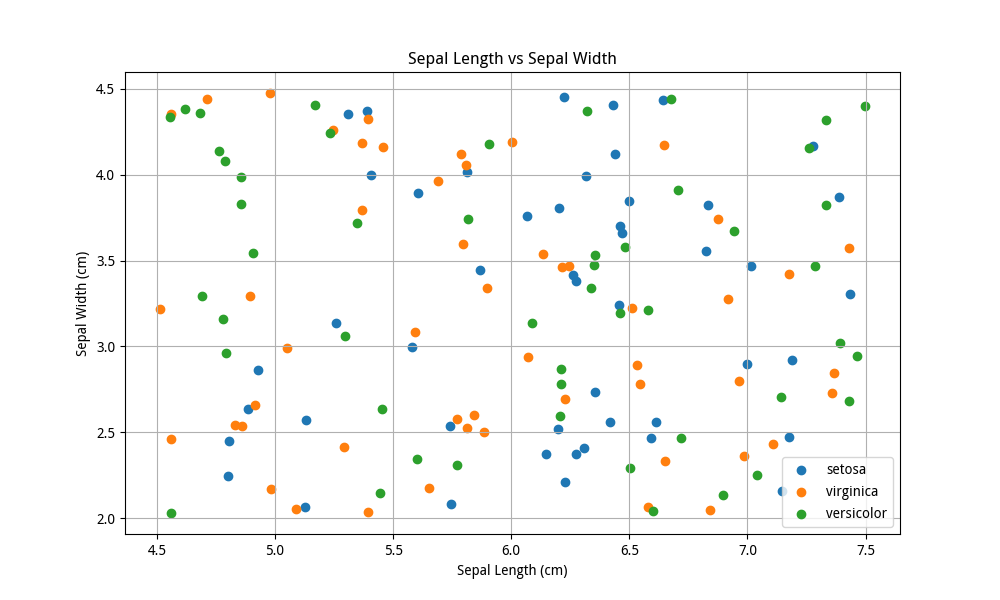

✓ iris_chart.png rendered above.


In [74]:
# Cell 19 — Display iris_chart.png inline
# read_file has no encoding param — read raw bytes via a Jupyter execute in sandbox
import base64, os, uuid
from agent_sandbox import Sandbox
from IPython.display import Image, display

sandbox_check = Sandbox(base_url=os.getenv("SANDBOX_URL", "http://localhost:8080"))

# Create a throwaway Jupyter session to base64-encode the PNG inside the sandbox
tmp_session = sandbox_check.jupyter.create_session(kernel_name="python3")
tmp_id = tmp_session.data.session_id

try:
    result = sandbox_check.jupyter.execute_code(
        code="import base64; print(base64.b64encode(open('/home/gem/iris_chart.png','rb').read()).decode())",
        session_id=tmp_id,
    )
    outputs = result.data.outputs or []
    b64 = ""
    for o in outputs:
        if getattr(o, "output_type", "") == "stream" and getattr(o, "text", None):
            b64 += o.text.strip()

    if b64:
        img_bytes = base64.b64decode(b64)
        display(Image(data=img_bytes))
        print("✓ iris_chart.png rendered above.")
    else:
        print("No base64 output received.")
except Exception as e:
    print(f"Could not display chart: {e}")
finally:
    try:
        sandbox_check.jupyter.delete_session(tmp_id)
    except Exception:
        pass